In [36]:
import os
import cv2
import matplotlib.pyplot as plt

In [37]:
from glob import glob
import os

DATASET_PATH = "../datasets/DeepGlobeDataset"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VALID_PATH = os.path.join(DATASET_PATH, "valid")
TEST_PATH = os.path.join(DATASET_PATH, "test")

In [38]:
train_images = glob(TRAIN_PATH + "/*_sat.jpg")
train_masks = glob(TRAIN_PATH + "/*_mask.png")

print("Training Images :", len(train_images))
print("Training Masks :", len(train_masks))

Training Images : 803
Training Masks : 803


In [39]:
print(train_images[:5])

['../datasets/DeepGlobeDataset\\train\\100694_sat.jpg', '../datasets/DeepGlobeDataset\\train\\102122_sat.jpg', '../datasets/DeepGlobeDataset\\train\\10233_sat.jpg', '../datasets/DeepGlobeDataset\\train\\103665_sat.jpg', '../datasets/DeepGlobeDataset\\train\\103730_sat.jpg']


In [40]:
train_images = glob(TRAIN_PATH + "/*_sat.jpg")
train_masks = glob(TRAIN_PATH + "/*_mask.png")

print("Training Images :", len(train_images))
print("Training Masks :", len(train_masks))
print(train_images[:5])

Training Images : 803
Training Masks : 803
['../datasets/DeepGlobeDataset\\train\\100694_sat.jpg', '../datasets/DeepGlobeDataset\\train\\102122_sat.jpg', '../datasets/DeepGlobeDataset\\train\\10233_sat.jpg', '../datasets/DeepGlobeDataset\\train\\103665_sat.jpg', '../datasets/DeepGlobeDataset\\train\\103730_sat.jpg']


Successfully loaded 803 images. Plotting first image...


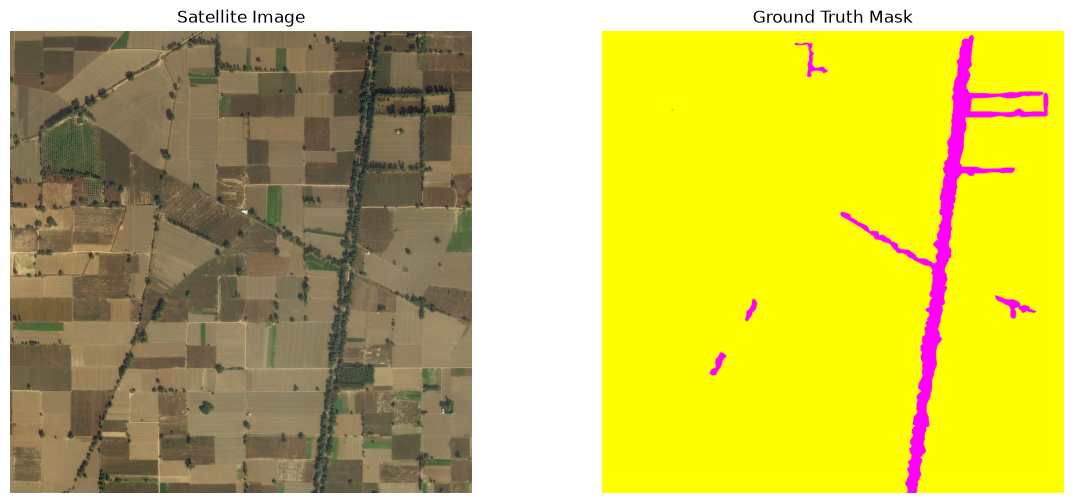

In [41]:
import os
import glob
import cv2
import matplotlib.pyplot as plt

# 1. Paths ko isiliye cell ke andar hi define kar dete hain taaki koi confusion na rahe
base_dir = os.path.abspath("..") 
image_dir = os.path.join(base_dir, "datasets", "DeepGlobeDataset", "train")

train_images = sorted(glob.glob(os.path.join(image_dir, "*_sat.jpg")))
train_masks = sorted(glob.glob(os.path.join(image_dir, "*_mask.png")))

# 2. Safety check lagate hain taaki error na aaye
if len(train_images) == 0:
    print("⚠️ Error: List abhi bhi khali hai! Ek baar apna 'base_dir' print karke manual path check karein.")
else:
    print(f"Successfully loaded {len(train_images)} images. Plotting first image...")
    
    # 3. First image and mask load & plot
    image = cv2.imread(train_images[0])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(train_masks[0])
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14,6))

    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("Satellite Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask)
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.show()

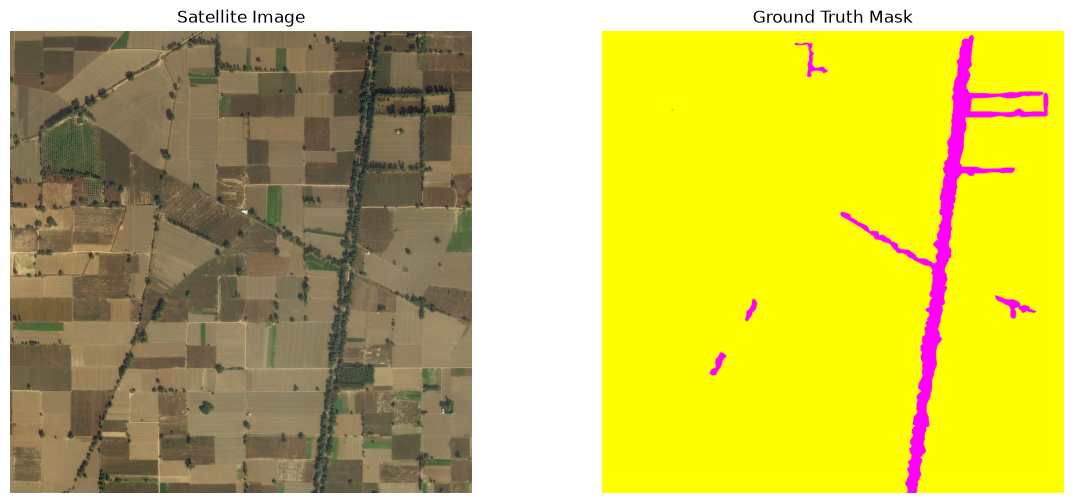

In [42]:
import cv2
import matplotlib.pyplot as plt

# First image
image = cv2.imread(train_images[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# First mask
mask = cv2.imread(train_masks[0])
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

In [43]:
import pandas as pd
import os

# Absolute path use karte hain taaki notebook se koi bhi reference issue na aaye
base_dir = os.path.abspath("..")
class_dict_path = os.path.join(base_dir, "datasets", "DeepGlobeDataset", "class_dict.csv")

# Agar folder ka naam directly project root mein hai:
if not os.path.exists(class_dict_path):
    # Safe check: directly root se match karke check karte hain
    class_dict_path = os.path.join(base_dir, "class_dict.csv")

print("Loading CSV from:", class_dict_path)
class_df = pd.read_csv(class_dict_path)
class_df

Loading CSV from: d:\project data\AI_afforestation\datasets\DeepGlobeDataset\class_dict.csv


,name,r,g,b
0,urban_land,0,255,255
1,agriculture_land,255,255,0
2,rangeland,255,0,255
3,forest_land,0,255,0
4,water,0,0,255
5,barren_land,255,255,255
6,unknown,0,0,0


In [44]:
print("Total Classes :", len(class_df))

print("\nClass Names:\n")

for cls in class_df["name"]:
    print(cls)

Total Classes : 7

Class Names:

urban_land
agriculture_land
rangeland
forest_land
water
barren_land
unknown


In [45]:
for index, row in class_df.iterrows():
    print(
        f"{row['name']} --> RGB({row['r']}, {row['g']}, {row['b']})"
    )

urban_land --> RGB(0, 255, 255)
agriculture_land --> RGB(255, 255, 0)
rangeland --> RGB(255, 0, 255)
forest_land --> RGB(0, 255, 0)
water --> RGB(0, 0, 255)
barren_land --> RGB(255, 255, 255)
unknown --> RGB(0, 0, 0)


In [46]:
import cv2

image = cv2.imread(train_images[0])

print("Original Shape:", image.shape)

Original Shape: (2448, 2448, 3)


In [47]:
image = cv2.resize(image, (512, 512))

print(image.shape)

(512, 512, 3)


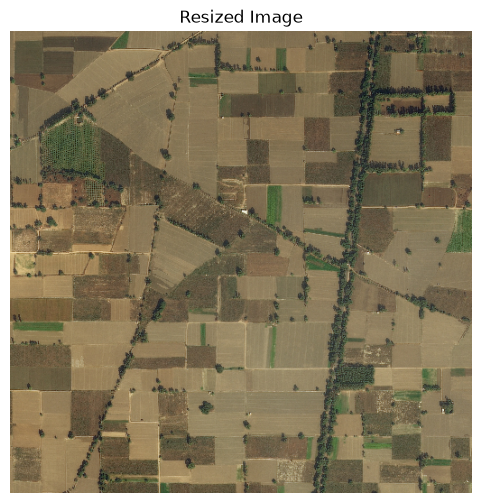

In [48]:
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Resized Image")
plt.show()

In [49]:
image = image / 255.0

print(image.min())
print(image.max())

0.0
0.9803921568627451


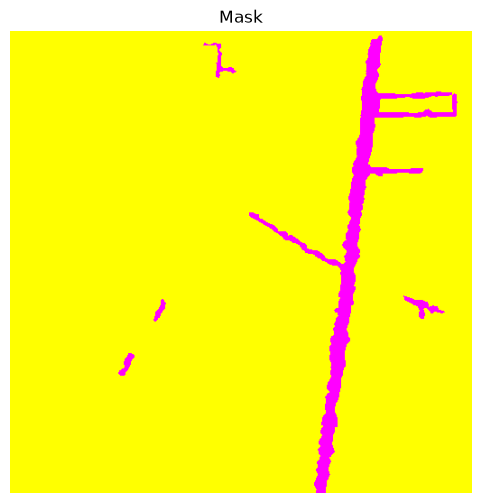

In [50]:
mask = cv2.imread(train_masks[0])

mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

mask = cv2.resize(mask, (512,512), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(6,6))
plt.imshow(mask)
plt.axis("off")
plt.title("Mask")
plt.show()

In [51]:
class_df = pd.read_csv("../datasets/DeepGlobeDataset/class_dict.csv")
print(class_df)


               name    r    g    b
0        urban_land    0  255  255
1  agriculture_land  255  255    0
2         rangeland  255    0  255
3       forest_land    0  255    0
4             water    0    0  255
5       barren_land  255  255  255
6           unknown    0    0    0


In [52]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from models.segmentation.dataset import DeepGlobeDataset

In [53]:
from models.segmentation.dataset import DeepGlobeDataset
import torch

dataset = DeepGlobeDataset(
    image_dir="../datasets/DeepGlobeDataset/train",
    mask_dir="../datasets/DeepGlobeDataset/train",
    image_size=512
)

print("Dataset Size:", len(dataset))

image, mask = dataset[0]

print("Image Shape:", image.shape)
print("Mask Shape:", mask.shape)
print("Mask Labels:", torch.unique(mask))

Dataset Size: 803
Image Shape: torch.Size([3, 512, 512])
Mask Shape: torch.Size([512, 512])
Mask Labels: tensor([1, 2])


In [54]:
image, mask = dataset[0]

In [55]:
dataset = DeepGlobeDataset(
    image_dir="datasets/DeepGlobeDataset/train",
    mask_dir="datasets/DeepGlobeDataset/train",
    image_size=512
)

In [56]:
import torch
from torch.utils.data import DataLoader

In [57]:
# 1. Pehle check karo dataset sach me khali hai ya nahi
print("Dataset size:", len(dataset))

Dataset size: 0


In [58]:
import os
import torch
from torch.utils.data import DataLoader
from models.segmentation.dataset import DeepGlobeDataset

# 1. Absolute paths define karein
base_dir = os.path.abspath("..") 
IMAGE_DIR = os.path.join(base_dir, "datasets", "DeepGlobeDataset", "train")
# Agar images aur masks dono same 'train' folder me hain toh dono ka path same hoga,
# bas extensions/suffixes alag honge jo dataset.py handle karta hai.
MASK_DIR = IMAGE_DIR 

print("Resolved Image Path:", IMAGE_DIR)

# 2. Dataset initialize karein
dataset = DeepGlobeDataset(image_dir=IMAGE_DIR, mask_dir=MASK_DIR, image_size=512)
print("Verified Dataset Size:", len(dataset))

# 3. Agar size > 0 hai, tabhi DataLoader banayein
if len(dataset) == 0:
    print("⚠️ Error: Abhi bhi 0 images mili hain! Dataset class ke andar files search karne ka pattern check karein.")
else:
    train_loader = DataLoader(
        dataset,
        batch_size=4,
        shuffle=True,
        num_workers=0 # Windows par 0 rakhna hi safe hai sub-processes conflicts se bachne ke liye
    )
    print("🎉 Success! DataLoader created perfectly.")
    
    # Ek batch fetch karke test karein
    images, masks = next(iter(train_loader))
    print("Batch Images Shape:", images.shape)
    print("Batch Masks Shape:", masks.shape)

Resolved Image Path: d:\project data\AI_afforestation\datasets\DeepGlobeDataset\train
Verified Dataset Size: 803
🎉 Success! DataLoader created perfectly.
Batch Images Shape: torch.Size([4, 3, 512, 512])
Batch Masks Shape: torch.Size([4, 512, 512])


In [59]:
train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

In [60]:
for images, masks in train_loader:

    print("Images:", images.shape)
    print("Masks :", masks.shape)

    break

Images: torch.Size([4, 3, 512, 512])
Masks : torch.Size([4, 512, 512])


In [61]:
import torch
import torchvision

print("Torch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)
print("CUDA Available:", torch.cuda.is_available())

Torch Version: 2.13.0+cu126
Torchvision Version: 0.28.0+cu126
CUDA Available: True


In [62]:
print(len(train_images))
print(len(train_masks))

803
803


In [63]:
print(train_images[:5])
print(train_masks[:5])


['d:\\project data\\AI_afforestation\\datasets\\DeepGlobeDataset\\train\\100694_sat.jpg', 'd:\\project data\\AI_afforestation\\datasets\\DeepGlobeDataset\\train\\102122_sat.jpg', 'd:\\project data\\AI_afforestation\\datasets\\DeepGlobeDataset\\train\\10233_sat.jpg', 'd:\\project data\\AI_afforestation\\datasets\\DeepGlobeDataset\\train\\103665_sat.jpg', 'd:\\project data\\AI_afforestation\\datasets\\DeepGlobeDataset\\train\\103730_sat.jpg']
['d:\\project data\\AI_afforestation\\datasets\\DeepGlobeDataset\\train\\100694_mask.png', 'd:\\project data\\AI_afforestation\\datasets\\DeepGlobeDataset\\train\\102122_mask.png', 'd:\\project data\\AI_afforestation\\datasets\\DeepGlobeDataset\\train\\10233_mask.png', 'd:\\project data\\AI_afforestation\\datasets\\DeepGlobeDataset\\train\\103665_mask.png', 'd:\\project data\\AI_afforestation\\datasets\\DeepGlobeDataset\\train\\103730_mask.png']


In [64]:
import os

print(TRAIN_PATH)
print(os.path.exists(TRAIN_PATH))

../datasets/DeepGlobeDataset\train
True


In [65]:
import glob
import os

# Notebooks folder se bahar nikal kar datasets folder ka absolute path nikalna
base_dir = os.path.abspath("..") # Taaki 'notebooks' folder se root folder par aa sakein
image_dir = os.path.join(base_dir, "datasets", "DeepGlobeDataset", "train") # Apne actual folder ke hisab se change karein

# DeepGlobe Dataset mein images "_sat.jpg" name se hoti hain
train_images = sorted(glob.glob(os.path.join(image_dir, "*_sat.jpg")))
train_masks = sorted(glob.glob(os.path.join(image_dir, "*_mask.png")))

Current Working Directory: d:\project data\AI_afforestation\notebooks
Expected Image Directory Path: d:\project data\AI_afforestation\datasets\DeepGlobeDataset\train
Total Images Found: 803
Total Masks Found: 803


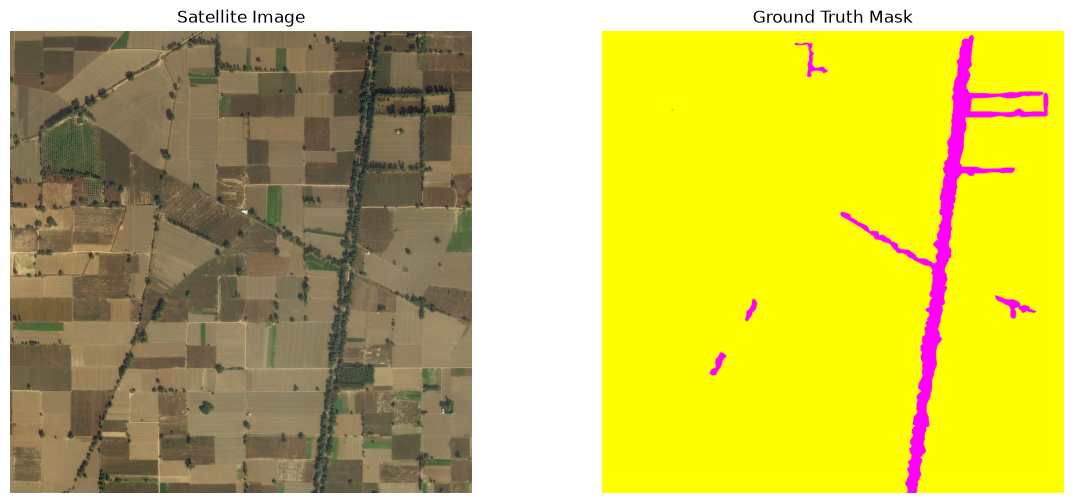

: 

In [ ]:
# Yeh code check karega ki path sahi hai ya nahi aur kitni files mili hain
print("Current Working Directory:", os.getcwd())
print("Expected Image Directory Path:", image_dir)
print("Total Images Found:", len(train_images))
print("Total Masks Found:", len(train_masks))
import cv2
import matplotlib.pyplot as plt

# First image
image = cv2.imread(train_images[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# First mask
mask = cv2.imread(train_masks[0])
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

# Plotting
plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()